In [1]:
# 7-7-2026

In [2]:
import pandas as pd
import numpy as np

In [3]:
true_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
true_matrix.set_index("Unnamed: 0", inplace=True)
true_matrix.index.name = None
true_matrix.index = true_matrix.index.astype(int)
true_matrix.columns = true_matrix.columns.astype(int)
true_matrix.head(10)

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [4]:
# for each domain (column), average all values except its own row (diagonal)
affinity = {}
for col in true_matrix.columns:
    col_vals = true_matrix[col].drop(index=col)  # drop self (i,i)
    affinity[col] = col_vals.mean()

In [5]:
affinity_df = pd.DataFrame(list(affinity.items()), columns=["domain_id", "avg_transfer_affinity"])
affinity_df = affinity_df.sort_values("avg_transfer_affinity", ascending=False).reset_index(drop=True)
affinity_df

,domain_id,avg_transfer_affinity
0,37,0.227504
1,1,0.160943
2,8,0.152708
3,0,0.151128
4,5,0.150446
5,33,0.135372
6,46,0.133983
7,32,0.130478
8,11,0.126173
9,25,0.123237


In [6]:
embeddings = pd.read_csv("domain_embeddings_v2.csv")

In [7]:
embeddings.head()

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7
0,0,0.320788,0.029515,0.493621,-0.254550,0.157485,0.043007,0.223810,-0.180119
1,1,0.035994,0.512844,0.735541,-1.007554,0.671355,0.219516,0.482659,-0.768034
2,2,0.258181,-0.175929,0.318462,0.016263,-0.086862,0.120247,-0.007532,-0.090168
3,4,0.360256,-0.026251,0.126985,0.132024,0.164264,-0.143251,-0.185669,0.135234
4,5,0.374883,-0.071358,0.552073,-0.290540,0.058007,0.202109,0.179068,-0.340887


In [8]:
# merge affinity into embeddings df (domain_id must match dtype, both should be int)
merged = embeddings.merge(affinity_df, on="domain_id", how="inner")

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [10]:
# drop id col, keep only embedding dims
feature_cols = [c for c in embeddings.columns if c.startswith("e_")]
X = merged[feature_cols].values

# fit pca 2d
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [11]:
print("explained variance ratio:", pca.explained_variance_ratio_)

explained variance ratio: [0.54043982 0.28686873]


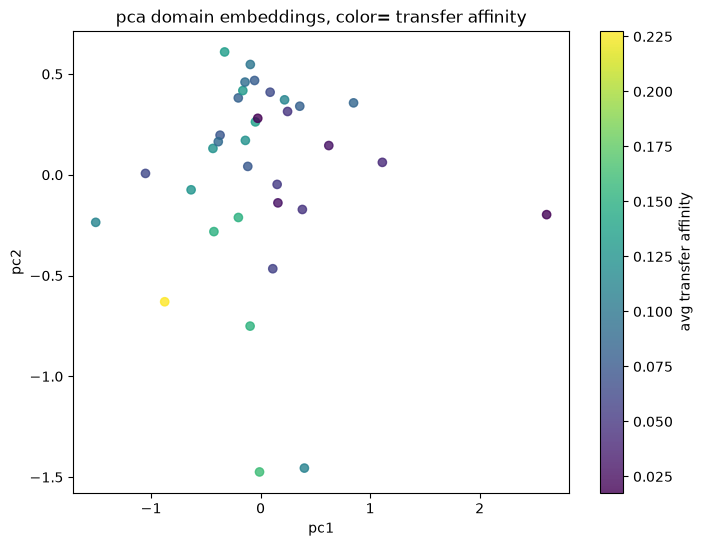

In [12]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=merged["avg_transfer_affinity"], cmap="viridis", alpha=0.8)
plt.colorbar(sc, label="avg transfer affinity")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca domain embeddings, color= transfer affinity")
plt.show()

In [13]:
corr_pc1 = np.corrcoef(merged["avg_transfer_affinity"], X_pca[:, 0])[0, 1]
corr_pc2 = np.corrcoef(merged["avg_transfer_affinity"], X_pca[:, 1])[0, 1]

print("corr with pc1:", corr_pc1)
print("corr with pc2:", corr_pc2)

corr with pc1: -0.5115132076930018
corr with pc2: -0.3252496778563607


In [14]:
from scipy.stats import pearsonr

r1, p1 = pearsonr(merged["avg_transfer_affinity"], X_pca[:, 0])
r2, p2 = pearsonr(merged["avg_transfer_affinity"], X_pca[:, 1])

print("pc1: r =", r1, "p =", p1)
print("pc2: r =", r2, "p =", p2)

pc1: r = -0.5115132076930016 p = 0.001988658685726957
pc2: r = -0.3252496778563607 p = 0.06052164895333737


In [15]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors

,domain_id,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
0,0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,...,0.479085,547.384100,1932.25460,1112.033700,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,...,0.499585,338.661650,1157.09030,705.891970,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,...,0.257699,3360.493400,8181.07230,8625.163000,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,...,0.411259,328.766850,739.65440,901.446350,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,...,0.447848,669.052060,2307.77000,1315.654900,0.185203,1.571907,0.090595,0.007227,0.615066,5
5,5,10.265495,5.699432,17.502420,2.046542,0.978449,3.276847,301.65985,5.860431,307.49870,...,0.491258,615.784000,2284.54270,1215.513500,0.141646,0.628370,0.270441,0.058533,0.560294,4
6,6,3.370416,3.105505,7.804835,3.172674,1.288420,4.654522,280.81445,12.255744,296.83127,...,0.394887,558.122500,2520.26320,715.896240,0.287090,2.909752,0.000000,0.003038,0.626834,4
7,7,11.621094,8.784235,24.302675,3.065614,1.245384,4.709380,295.90033,8.041678,307.00922,...,0.286967,513.446900,1531.67580,1095.658200,0.117847,0.972292,0.076211,0.004830,0.655366,3
8,8,7.512378,2.146205,10.056996,1.712309,1.128670,3.099993,302.63660,2.228121,305.12260,...,0.488031,328.441350,895.73500,747.977050,0.100920,0.937725,0.149864,0.019789,0.553258,5
9,9,3.658946,1.855246,6.112502,3.419243,1.666298,5.511101,287.73157,4.825871,294.05838,...,0.401618,1132.007300,4253.38570,1966.245800,0.543724,5.499713,0.000000,0.002421,0.625943,2


In [16]:
from sklearn.preprocessing import StandardScaler

# drop domain_id, keep feature cols
desc_feature_cols = [c for c in descriptors.columns if c != "domain_id"]
X_desc = descriptors[desc_feature_cols].values

# scale first, raw features have very different ranges
scaler = StandardScaler()
X_desc_scaled = scaler.fit_transform(X_desc)

In [17]:
pca_desc = PCA(n_components=2)
X_desc_pca = pca_desc.fit_transform(X_desc_scaled)

print("explained variance ratio:", pca_desc.explained_variance_ratio_)


explained variance ratio: [0.37203337 0.19409356]


In [19]:
merged_desc = descriptors[descriptors["domain_id"].isin(merged["domain_id"])].reset_index(drop=True)

# make sure order matches merged, so affinity lines up with the right domain
merged_desc = merged_desc.set_index("domain_id").loc[merged["domain_id"]].reset_index()

desc_feature_cols = [c for c in merged_desc.columns if c != "domain_id"]
X_desc = merged_desc[desc_feature_cols].values

scaler = StandardScaler()
X_desc_scaled = scaler.fit_transform(X_desc)

pca_desc = PCA(n_components=2)
X_desc_pca = pca_desc.fit_transform(X_desc_scaled)

print("explained variance ratio:", pca_desc.explained_variance_ratio_)

explained variance ratio: [0.42395038 0.21601678]


In [20]:
r1d, p1d = pearsonr(merged["avg_transfer_affinity"], X_desc_pca[:, 0])
r2d, p2d = pearsonr(merged["avg_transfer_affinity"], X_desc_pca[:, 1])

print("pc1: r =", r1d, "p =", p1d)
print("pc2: r =", r2d, "p =", p2d)

pc1: r = 0.2631485426881489 p = 0.13266951439106922
pc2: r = 0.23090517448249712 p = 0.18888860447354883


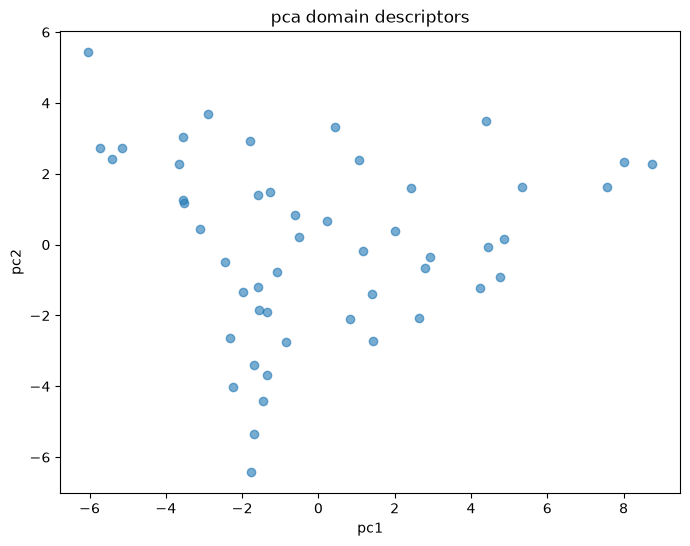

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(X_desc_pca[:, 0], X_desc_pca[:, 1], alpha=0.6)
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca domain descriptors")
plt.show()

In [29]:
# corr matrix between embedding dims and raw descriptors
merged_full = embeddings.merge(descriptors, on="domain_id", how="inner")

emb_cols = [c for c in embeddings.columns if c.startswith("e_")]
desc_cols = [c for c in descriptors.columns if c != "domain_id"]

corr_matrix = merged_full[emb_cols + desc_cols].corr(method="spearman").loc[emb_cols, desc_cols]
corr_matrix

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
e_0,0.451490,0.497937,0.481436,0.395569,0.275172,0.394958,0.212529,-0.016654,0.369595,-0.509244,...,-0.297173,0.596333,0.563942,0.640947,0.432544,0.233002,0.224771,-0.040794,-0.156914,-0.294874
e_1,-0.403514,-0.421238,-0.424599,-0.361039,-0.036516,-0.313980,-0.148663,0.047212,-0.321925,0.357983,...,0.317036,-0.807181,-0.811459,-0.771123,-0.628113,-0.465546,-0.340061,-0.101299,-0.240642,0.178902
e_2,0.042322,-0.160581,-0.058212,-0.273644,-0.240336,-0.229641,0.292895,-0.514133,0.046295,0.332009,...,0.343927,0.293201,0.286784,0.299312,0.544996,0.349733,0.511162,0.262643,-0.004736,-0.269451
e_3,-0.209167,0.009931,-0.095493,0.598167,0.551719,0.653782,-0.570970,0.536746,-0.336898,-0.530023,...,-0.383652,0.336593,0.387930,0.241253,0.357983,0.547135,-0.315444,-0.354927,0.492437,-0.226295
e_4,-0.169748,-0.150191,-0.160581,-0.174637,-0.017265,-0.183499,-0.013904,0.157830,-0.056379,0.108938,...,0.157219,-0.612834,-0.653782,-0.572498,-0.700229,-0.628113,-0.296025,-0.146218,-0.468908,0.266626
e_5,0.029488,-0.218029,-0.084798,-0.538273,-0.694423,-0.596028,0.356455,-0.621085,0.049656,0.663254,...,0.356455,0.175248,0.174332,0.166998,0.398625,0.162414,0.597095,0.627502,0.083270,-0.093531
e_6,0.221696,-0.071963,0.086020,-0.515355,-0.483270,-0.560275,0.534607,-0.713675,0.255309,0.593888,...,0.390680,0.075936,0.074408,0.148358,0.299312,0.133384,0.547401,0.602750,-0.052101,0.079093
e_7,0.046600,0.327731,0.181360,0.702368,0.736898,0.760122,-0.420932,0.670283,-0.023071,-0.821543,...,-0.526662,0.032238,0.051795,0.006264,-0.122078,0.127578,-0.607340,-0.727731,0.086020,-0.010044


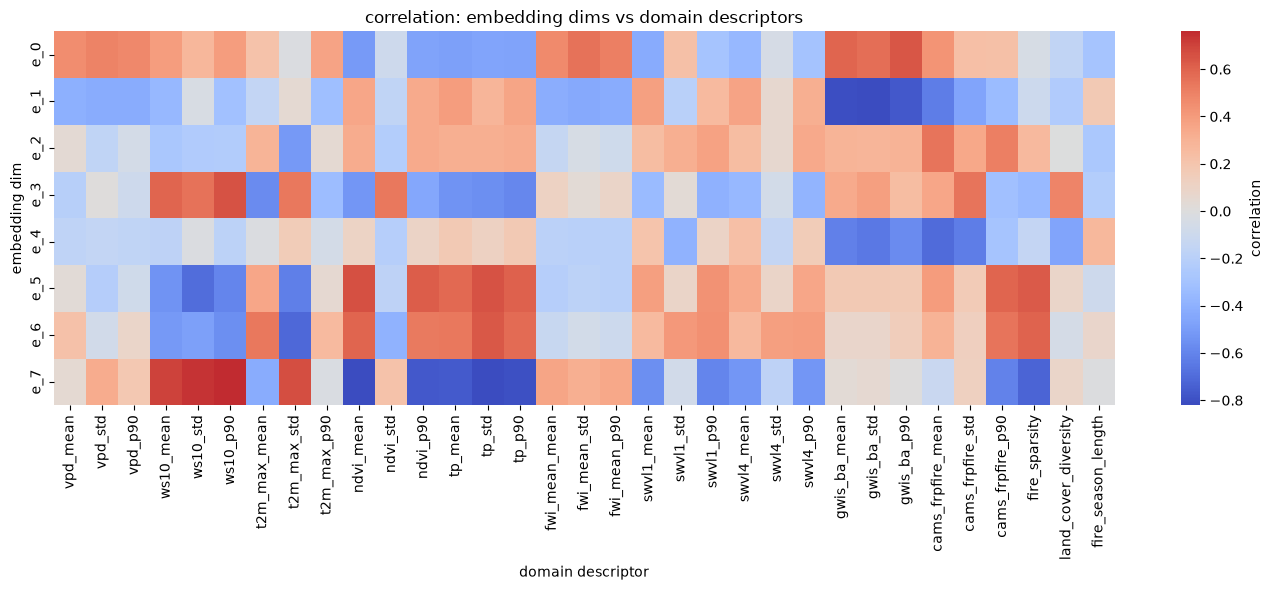

In [30]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar_kws={"label": "correlation"})
plt.xlabel("domain descriptor")
plt.ylabel("embedding dim")
plt.title("correlation: embedding dims vs domain descriptors")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# lots of redundancy across which domain descriptors best get encoded

In [31]:
# average absolute corr per embedding dim, across all descriptors
avg_abs_corr = corr_matrix.abs().mean(axis=1).sort_values(ascending=False)
avg_abs_corr

e_7    0.402638
e_0    0.362683
e_3    0.359398
e_1    0.351124
e_5    0.341233
e_6    0.338086
e_2    0.254926
e_4    0.246515
dtype: float64

In [ ]:
# embedding dims aren't collapsing into one direction, correlations spread out over
#    multiple physically distinct descriptors (wind, vpd, ndvi, land cover)
# each dim is a learned combination of multiple raw descriptors, 
#   capturing some latent reperestaion that doesn't exist explicitly in the raw feature set
# mid level correlations across the board mean encoder is mixing features together in its embeddings, which is cool
#  the encoder's top learned direction tracks transfer affinity better
#   than the raw descriptor's top pca dirction does

In [33]:
# still need to do mapping to pyromes